# Deep Q-learning

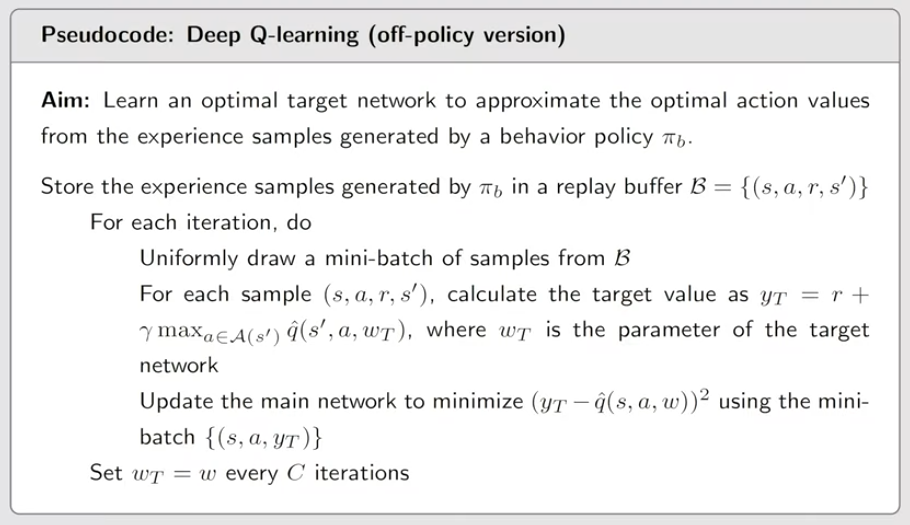

## Implementation

In [4]:
import random
import torch
from torch import nn 
from torch import optim
from collections import deque

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)

In [5]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.ffn = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, state):
        return self.ffn(state)

In [6]:
class ReplayBuffer:
    def __init__(self, maxlen=5000):
        self.buffer = deque(maxlen=maxlen)
        
    def append(self, s, a, r, s_next, is_terminated):
        self.buffer.append((s, a, r, s_next, is_terminated))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, is_terminated = map(np.array, zip(*batch))
        return s, a, r, s_next, is_terminated

    def __len__(self):
        return len(self.buffer)

In [7]:
# replay_buffer = ReplayBuffer(2)
# replay_buffer.append(1, 2, -1, 4, False)
# replay_buffer.append(5, 0, 0, 1, False)
# replay_buffer.sample(2)

In [8]:
q_net = QNetwork(10, 4)
# q_net.ffn[-1].out_features ---> action dim
# q_net.ffn[0].in_features ---> state_dim

In [9]:
# TO do: implement epsilon decaying over time

def epsilon_greedy_policy(q_net, state, env, epsilon=0.2):
    actions = env.all_action_idx 
    if random.random() < epsilon:
        return random.choice(actions) # <---- exploration
    else:
        state = torch.FloatTensor(state).unsqueeze(0) # batch X state_dim
        with torch.no_grad():
            q_values = q_net(state)  # batch X n_actions   
        return q_values.argmax(dim=1).item() # exploit

In [10]:
def get_approx_Qsa(q_net, state, action=None):
    state = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        q_values = q_net(state)
    if action is None:
        return q_values
    return q_values[action]

def get_max_Q_s(q_net, state, keepdim=True):
    state = torch.FloatTensor(state)
    with torch.no_grad():
        q_values = q_net(state)
    return q_values.max(dim=1, keepdim=keepdim)[0]

def get_argmax_Q_s(q_net, state):
    state = torch.FloatTensor(state)
    with torch.no_grad():
        q_values = q_net(state)
    return q_values.argmax(dim=1).item()

In [38]:
def get_policy_table(q_net, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    policy = np.zeros(env.n_states, dtype=np.int8)

    for state in states:
        state_feat_vec = state.get_state_feature_vec(env.n_states)
        state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
        policy[state.idx] = get_argmax_Q_s(q_net, state_feat_vec)
    return policy


def get_Q_table(q_net, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.int8)
    for state in states:
        state_feat_vec = state.get_state_feature_vec(env.n_states)
        state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
        q_values = get_approx_Qsa(q_net, state_feat_vec)
        Q[state.idx, :] = np.asarray(q_values)
    return Q

In [127]:
def train_step(env, online_net, target_net, optimizer, loss_fn,
               replay_buffer, batch_size=64, gamma=0.1):

    if len(replay_buffer) < batch_size:
        return

    s, a, r, next_s, is_terminated = replay_buffer.sample(batch_size)

    s = torch.Tensor(s) # batch X feat_vec
    a = torch.LongTensor(a).unsqueeze(1) # batch X 1
    r = torch.Tensor(r).unsqueeze(1) # batch X 1
    next_s = torch.Tensor(next_s) # batch X feat_vec

    is_terminated = torch.Tensor(is_terminated).unsqueeze(1)
    
    # Q(s, a; w_o) --->  q value of the corresponding action
    q_sa = online_net(s).gather(1, a)

    # Y_T =  r + γ max Q(s',a; W_T)
    with torch.no_grad():
        max_next_q = get_max_Q_s(target_net, next_s)
        y_T = r + gamma * max_next_q * (1 - is_terminated)

    # print("y T shape: ", y_T.shape)
    # print("q sa shape: ", q_sa.shape)
    
    loss = loss_fn(q_sa, y_T)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()    

In [40]:
# online_net = QNetwork(16, 4)
# x = torch.from_numpy(np.zeros((2, 16), dtype=np.float32))
# out = online_net(x)
# # print(out.shape)
# print(out.max(dim=1)[0].shape)
# # print(out.argmax(dim=1))
# print(out.max(dim=1, keepdim=True)[0].shape)

In [155]:
def run_deep_q_learning(env, n_episodes=500, epsilon=0.7, 
                        epsilon_decay=0.01, gamma=0.99, lr=0.0001,
                        batch_size=64, target_update_freq=50):
    
    policy_histories = []
    Q_histories = []
    trajectory_histories = []

    online_net = QNetwork(env.n_states, env.n_actions)
    target_net = QNetwork(env.n_states, env.n_actions)

    target_net.load_state_dict(online_net.state_dict())
    target_net.eval()
    optimizer = optim.Adam(online_net.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    replay_buffer = ReplayBuffer()

    rewards = []
    for episode_idx in range(n_episodes):
        # --- initial state action pair -----
        state = env.find('S') 
        action = 2 #randomly picked
        # -----------------------------------
        
        state_feature_vec = state.get_state_feature_vec(env.n_states)
        
        is_terminated = False
        episode_reward = 0
        trajectory = []

        # ----- epsilon decay -----------------------
        epsilon = max(0.05, epsilon - epsilon_decay)
        # -------------------------------------------
        
        while not is_terminated: # run iteration
            trajectory.append(state.coord)

            action = epsilon_greedy_policy(online_net,
                                           state_feature_vec,
                                           env,
                                           epsilon=epsilon)
            
            result = env.step(state, action)
            reward = result["reward"]
            next_state = result["new_state"]
           
            next_state_feature_vec = next_state.get_state_feature_vec(env.n_states)
            
            is_terminated = result["is_terminated"]
        
            replay_buffer.append(state_feature_vec,
                                 action,
                                 reward,
                                 next_state_feature_vec,
                                 is_terminated)

            train_step(
                    env,
                    online_net,
                    target_net, 
                    optimizer, 
                    loss_fn,
                    replay_buffer,
                    batch_size,
                    gamma)
 
            state_feature_vec = next_state_feature_vec
            state = next_state
            episode_reward += reward
            
        trajectory.append(state.coord)
        rewards.append(episode_reward)

        trajectory_histories.append(trajectory)
        
        if episode_idx % target_update_freq == 0:
            target_net.load_state_dict(online_net.state_dict())
            target_net.eval()
            
        if episode_idx % 500 == 0:
            avg = np.mean(rewards[-100:])
            print(f"Episode {episode_idx} | Avg Reward (100): {avg:.3f} | epsilon={epsilon}")
            policy = get_policy_table(online_net, env)
            Q_table = get_Q_table(online_net, env)
            
            policy_histories.append(policy)
            Q_histories.append(Q_table)
            
    return {"policy_histories": policy_histories,
            "q_histories": Q_histories, 
            "trajectory_histories": trajectory_histories}

## Setup frozen lake environment

In [156]:
lake_grid = [["F", "F", "S", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points = reward_points,
                                    slippery=True)

## Run deep Q algorithm

In [159]:
histories = run_deep_q_learning(frozen_lake, 
                                n_episodes=1000, 
                                epsilon=0.7,
                                epsilon_decay = 0.001)

Episode 0 | Avg Reward (100): 0.000 | epsilon=0.699
Episode 500 | Avg Reward (100): 5.100 | epsilon=0.1989999999999995


In [160]:
policy = histories["policy_histories"][-1] #optimum policy
q_table = histories["q_histories"][-1]

In [161]:
policy

array([2, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2, 1, 0, 2, 2, 2], dtype=int8)

In [162]:
q_table

array([[4, 4, 5, 4],
       [4, 5, 6, 5],
       [5, 1, 7, 6],
       [7, 8, 8, 8],
       [4, 5, 5, 4],
       [3, 6, 2, 4],
       [4, 3, 5, 4],
       [3, 8, 7, 7],
       [5, 3, 6, 5],
       [5, 2, 8, 5],
       [6, 6, 9, 8],
       [4, 6, 6, 5],
       [2, 2, 2, 2],
       [5, 5, 7, 6],
       [4, 5, 6, 6],
       [5, 7, 8, 7]], dtype=int8)

In [163]:
len(histories["trajectory_histories"])

1000

In [164]:
print(histories["trajectory_histories"][:5])

[[(0, 2), (1, 2)], [(0, 2), (1, 2)], [(0, 2), (0, 2), (0, 1), (0, 1), (0, 1), (0, 0), (0, 1), (0, 0), (0, 0), (1, 0), (1, 0), (1, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (2, 1), (2, 2), (3, 2), (2, 2), (2, 3)], [(0, 2), (0, 3), (0, 2), (0, 3), (1, 3), (1, 2)], [(0, 2), (0, 1), (0, 0), (1, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 1), (1, 1), (1, 2)]]


# Render policy and trajectories

In [165]:
import pandas as pd
from IPython.display import display

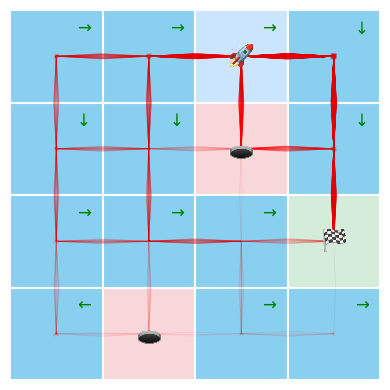

In [166]:
plot_trajectory_history(frozen_lake,histories["trajectory_histories"], policy)

## Play with different grid setup

In [167]:
grid = generate_grid_randomly(4, 4, n_holes=4)
grid

[['H', 'H', 'F', 'F'],
 ['F', 'F', 'F', 'S'],
 ['G', 'F', 'H', 'F'],
 ['F', 'F', 'F', 'H']]

In [168]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [170]:
histories = run_deep_q_learning(frozen_lake,
                                n_episodes=5000,
                                epsilon=0.2,
                                epsilon_decay=0)

Episode 0 | Avg Reward (100): 0.000 | epsilon=0.2
Episode 500 | Avg Reward (100): 5.000 | epsilon=0.2
Episode 1000 | Avg Reward (100): 4.800 | epsilon=0.2
Episode 1500 | Avg Reward (100): 4.800 | epsilon=0.2
Episode 2000 | Avg Reward (100): 4.800 | epsilon=0.2
Episode 2500 | Avg Reward (100): 4.800 | epsilon=0.2
Episode 3000 | Avg Reward (100): 5.100 | epsilon=0.2
Episode 3500 | Avg Reward (100): 4.200 | epsilon=0.2
Episode 4000 | Avg Reward (100): 4.900 | epsilon=0.2
Episode 4500 | Avg Reward (100): 5.100 | epsilon=0.2


In [171]:
policy = histories["policy_histories"][-1]

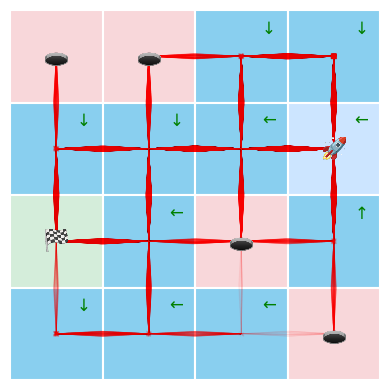

In [172]:
plot_trajectory_history(frozen_lake,
                        histories["trajectory_histories"],
                        policy=policy)